In [18]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt

In [19]:
data=pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [20]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
data=np.array(data)
m,n=data.shape
np.random.shuffle(data)

data_dev=data[0:1000].T
X_dev=data_dev[1:n]
Y_dev=data_dev[0]

data_train=data[1000:m].T
X_train=data_train[1:n]
Y_train=data_train[0]

# Normalizing
X_train = X_train / 255.0
X_dev   = X_dev   / 255.0

In [22]:
X_train[:,0].shape

(784,)

In [23]:
def init_params() :
    W1 = np.random.randn(64,784) * np.sqrt(2/784)
    W2 = np.random.randn(10,64) * np.sqrt(2/64)

    B1 = np.zeros((64,1))
    B2 = np.zeros((10,1))
    #He Initialization
    return W1,B1,W2,B2

def ReLU(Z) :
    return np.maximum(0, Z)

def deriv_ReLU(Z): 
    return Z>0

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def forward_prop(W1,B1,W2,B2,X) :
    Z1=W1.dot(X) + B1
    A1=ReLU(Z1)
    Z2=W2.dot(A1) + B2
    A2=softmax(Z2)
    return Z1, A1, Z2, A2

def one_hot(Y):
    one_hot_Y=np.zeros((Y.size, Y.max()+1))
    one_hot_Y[np.arange(Y.size),Y]=1
    return one_hot_Y.T

def back_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    hot = one_hot(Y)
    m = Y.size
    dZ2 = A2 - hot
    dW2 = (1/m) * dZ2.dot(A1.T)
    dB2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
    dW1 = (1/m) * dZ1.dot(X.T)
    dB1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, dB1, dW2, dB2

def update_params(W1,B1,W2,B2,dW1,dB1,dW2,dB2,alpha):
    W1 = W1 - alpha * dW1
    B1 = B1 - alpha * dB1    
    W2 = W2 - alpha * dW2  
    B2 = B2 - alpha * dB2    
    return W1, B1, W2, B2    

In [33]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size
#Added loss function
def cross_entropy_loss(A2,Y):
    #loss = -np.mean(np.log(A2[Y, np.arange(Y.size)] + 1e-8))
    loss = -np.sum(one_hot(Y) * np.log(A2 + 1e-8)) / Y.size
    return loss

def gradient_descent(X, Y, alpha, iterations):
    accuracy_history = []
    loss_history = []
    
    W1, B1, W2, B2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, B1, W2, B2, X)
        dW1, dB1, dW2, dB2 = back_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, B1, W2, B2 = update_params(W1, B1, W2, B2, dW1, dB1, dW2, dB2, alpha)
        accuracy_history.append(get_accuracy(get_predictions(A2), Y))
        loss_history.append(cross_entropy_loss(A2,Y))
        if i % 100 == 0:
            predictions = get_predictions(A2)
            print("Iteration:", i," | ","ACCURACY:",get_accuracy(predictions, Y)," | ","LOSS:", cross_entropy_loss(A2,Y))
            #predictions = get_predictions(A2)
            #print("ACCURACY: ",get_accuracy(predictions, Y))
            #print("LOSS: ", cross_entropy_loss(A2,Y))
    return W1, B1, W2, B2,accuracy_history,loss_history

def plot_metrics(accuracy_history, loss_history):
    epochs = range(len(accuracy_history))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(epochs, accuracy_history)
    ax1.set_title('Training Accuracy')
    ax1.set_xlabel('Iterations (x100)')
    ax1.set_ylabel('Accuracy')

    ax2.plot(epochs, loss_history, color='red')
    ax2.set_title('Cross-Entropy Loss')
    ax2.set_xlabel('Iterations (x100)')
    ax2.set_ylabel('Loss')

    plt.tight_layout()
    plt.show()

Iteration: 0  |  ACCURACY: 0.11756097560975609  |  LOSS: 2.3685136902926676
Iteration: 100  |  ACCURACY: 0.624  |  LOSS: 1.681109117501252
Iteration: 200  |  ACCURACY: 0.7555609756097561  |  LOSS: 1.1761544436750098
Iteration: 300  |  ACCURACY: 0.8090975609756098  |  LOSS: 0.9011060309280304
Iteration: 400  |  ACCURACY: 0.8323658536585365  |  LOSS: 0.7482801498285564
Iteration: 500  |  ACCURACY: 0.8475609756097561  |  LOSS: 0.6544616750951103
Iteration: 600  |  ACCURACY: 0.8573658536585366  |  LOSS: 0.5915706372065965
Iteration: 700  |  ACCURACY: 0.8648536585365854  |  LOSS: 0.5464547353823752
Iteration: 800  |  ACCURACY: 0.8713658536585366  |  LOSS: 0.5124519264373691
Iteration: 900  |  ACCURACY: 0.876390243902439  |  LOSS: 0.4858140594846052
Iteration: 1000  |  ACCURACY: 0.8804878048780488  |  LOSS: 0.46427445780582205


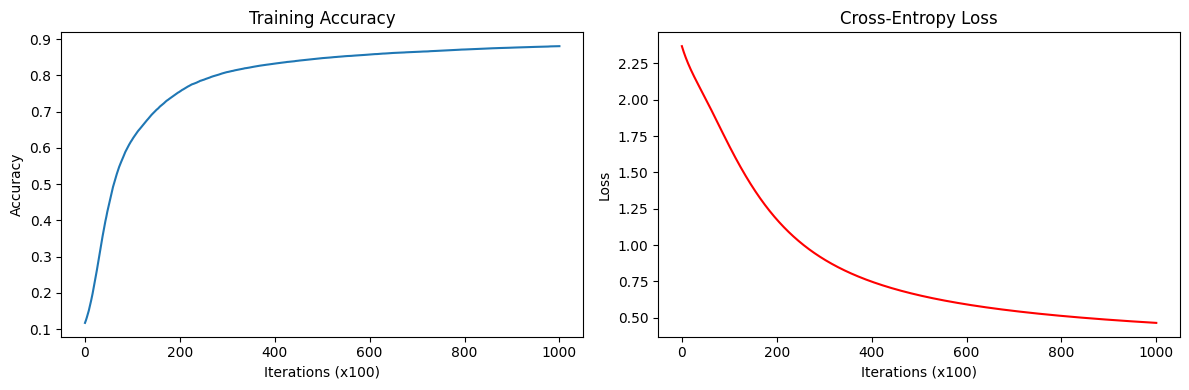

In [34]:
W1, B1, W2, B2,acc, loss = gradient_descent(X_train, Y_train, 0.01, 1001)
plot_metrics(acc,loss)